<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-student-migration-ml-90-6?scriptVersionId=249060683" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-student-migration-and-higher-education-trends/global_student_migration.csv


## Title: 
Global Student Migration & Higher Education Trends

##  Description
"Global Student Migration & Higher Education Trends" examines the dynamic landscape of international student movement and the transformations shaping higher education worldwide. In recent decades, the globalization of education has led to a significant increase in the mobility of students across borders. This trend is driven by factors such as the pursuit of quality education, access to better career opportunities, scholarship programs, and international collaboration among universities.

The report explores how traditional destination countries like the United States, United Kingdom, Canada, and Australia continue to attract large numbers of international students, while emerging education hubs in Asia (e.g., China, Singapore, South Korea) and parts of Europe (e.g., Germany, Netherlands) are increasingly becoming preferred alternatives due to lower tuition costs, quality programs, and favorable visa policies.

Additionally, the analysis highlights how the COVID-19 pandemic disrupted global student flows and accelerated the adoption of digital and hybrid learning models. The growing role of online education, virtual student exchange programs, and remote internships has redefined how students engage with institutions and international experiences.

The description also includes a discussion on policy implications, including immigration reforms, post-study work rights, and the balance between national interests and global talent acquisition. Issues like brain drain in developing countries versus brain gain in destination countries are examined to understand the socio-economic impact of student migration.

## Import dataset

## 

In [2]:
df = pd.read_csv('/kaggle/input/global-student-migration-and-higher-education-trends/global_student_migration.csv')

In [3]:
df.head()

,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
0,S00001,Finland,Russia,Moscow,Lomonosov Moscow State University,Computer Science,Engineering,2021,No,Higher Ranking,2024,Placed,Russia,Microsoft,36416,3.92,Tier 4,Work Permit,TOEFL,7.8
1,S00002,UK,Germany,Aachen,RWTH Aachen,Civil Engineering,Law,2023,Yes,Job Opportunities,2024,Placed,Germany,Google,32956,2.60,Study Permit,OPT,PTE,7.9
2,S00003,Ireland,Canada,Vancouver,University of British Columbia,Law,Arts,2019,No,Scholarship,2020,Not Placed,NaN,NaN,0,2.72,F1,Blue Card,NaN,0.0
3,S00004,UAE,UK,Birmingham,University of Birmingham,Data Science,Social Sciences,2021,Yes,Quality of Life,2023,Placed,UK,Apple,50892,3.71,Schengen Student Visa,PSW,NaN,0.0
4,S00005,South Africa,Germany,Stuttgart,University of Stuttgart,Business Administration,Law,2020,Yes,Political Stability,2021,Placed,Germany,IBM,54790,2.96,Schengen Student Visa,OPT,PTE,8.2


In [4]:
df.tail()

,student_id,origin_country,destination_country,destination_city,university_name,course_name,field_of_study,year_of_enrollment,scholarship_received,enrollment_reason,graduation_year,placement_status,placement_country,placement_company,starting_salary_usd,gpa_or_score,visa_status,post_graduation_visa,language_proficiency_test,test_score
4995,S04996,Canada,Germany,Stuttgart,University of Stuttgart,Political Science,Engineering,2023,No,Scholarship,2024,Placed,Germany,Facebook,98568,3.96,Tier 4,Post-Study Visa,Duolingo,6.9
4996,S04997,India,Ireland,Maynooth,Maynooth University,Political Science,Law,2023,Yes,Quality of Life,2026,Placed,Ireland,Deloitte,32643,3.93,F1,PSW,TOEFL,7.5
4997,S04998,UK,India,Bangalore,IISc Bangalore,Finance,Natural Sciences,2023,Yes,Scholarship,2026,Placed,India,Tesla,100777,3.76,Study Permit,Post-Study Visa,TOEFL,8.8
4998,S04999,Germany,Russia,Saint Petersburg,Saint Petersburg State University,Biotechnology,Business,2020,Yes,Scholarship,2022,Not Placed,NaN,NaN,0,3.72,Schengen Student Visa,Blue Card,IELTS,8.6
4999,S05000,Finland,Germany,Stuttgart,University of Stuttgart,Mechanical Engineering,Arts,2023,No,Scholarship,2026,Placed,Germany,IBM,72268,3.78,Schengen Student Visa,Work Permit,PTE,5.6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 5000 non-null   object 
 1   origin_country             5000 non-null   object 
 2   destination_country        5000 non-null   object 
 3   destination_city           5000 non-null   object 
 4   university_name            5000 non-null   object 
 5   course_name                5000 non-null   object 
 6   field_of_study             5000 non-null   object 
 7   year_of_enrollment         5000 non-null   int64  
 8   scholarship_received       5000 non-null   object 
 9   enrollment_reason          5000 non-null   object 
 10  graduation_year            5000 non-null   int64  
 11  placement_status           5000 non-null   object 
 12  placement_country          2509 non-null   object 
 13  placement_company          2509 non-null   objec

In [6]:
df.describe()

,year_of_enrollment,graduation_year,starting_salary_usd,gpa_or_score,test_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2021.011000,2023.017800,44552.531000,3.246820,5.632200
std,1.420733,1.651432,50719.190623,0.430659,2.973838
min,2019.000000,2020.000000,0.000000,2.500000,0.000000
25%,2020.000000,2022.000000,0.000000,2.877500,5.300000
50%,2021.000000,2023.000000,30516.500000,3.240000,6.500000
75%,2022.000000,2024.000000,87838.500000,3.610000,7.800000
max,2023.000000,2026.000000,149932.000000,4.000000,9.000000


In [7]:
df.isnull().sum()

student_id                      0
origin_country                  0
destination_country             0
destination_city                0
university_name                 0
course_name                     0
field_of_study                  0
year_of_enrollment              0
scholarship_received            0
enrollment_reason               0
graduation_year                 0
placement_status                0
placement_country            2491
placement_company            2491
starting_salary_usd             0
gpa_or_score                    0
visa_status                     0
post_graduation_visa            0
language_proficiency_test     982
test_score                      0
dtype: int64

In [8]:
df.dtypes

student_id                    object
origin_country                object
destination_country           object
destination_city              object
university_name               object
course_name                   object
field_of_study                object
year_of_enrollment             int64
scholarship_received          object
enrollment_reason             object
graduation_year                int64
placement_status              object
placement_country             object
placement_company             object
starting_salary_usd            int64
gpa_or_score                 float64
visa_status                   object
post_graduation_visa          object
language_proficiency_test     object
test_score                   float64
dtype: object

In [9]:
df.shape

(5000, 20)

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['student_id', 'origin_country', 'destination_country',
       'destination_city', 'university_name', 'course_name', 'field_of_study',
       'year_of_enrollment', 'scholarship_received', 'enrollment_reason',
       'graduation_year', 'placement_status', 'placement_country',
       'placement_company', 'starting_salary_usd', 'gpa_or_score',
       'visa_status', 'post_graduation_visa', 'language_proficiency_test',
       'test_score'],
      dtype='object')

## Data visualizations

In [12]:
import plotly.express as px


In [13]:
# 1. Student Migration Heatmap (Origin -> Destination)
migration = df.groupby(['origin_country', 'destination_country']).size().reset_index(name='count')
fig1 = px.sunburst(migration, path=['origin_country', 'destination_country'], values='count',
                   title='Global Student Migration Flow')
fig1.show()

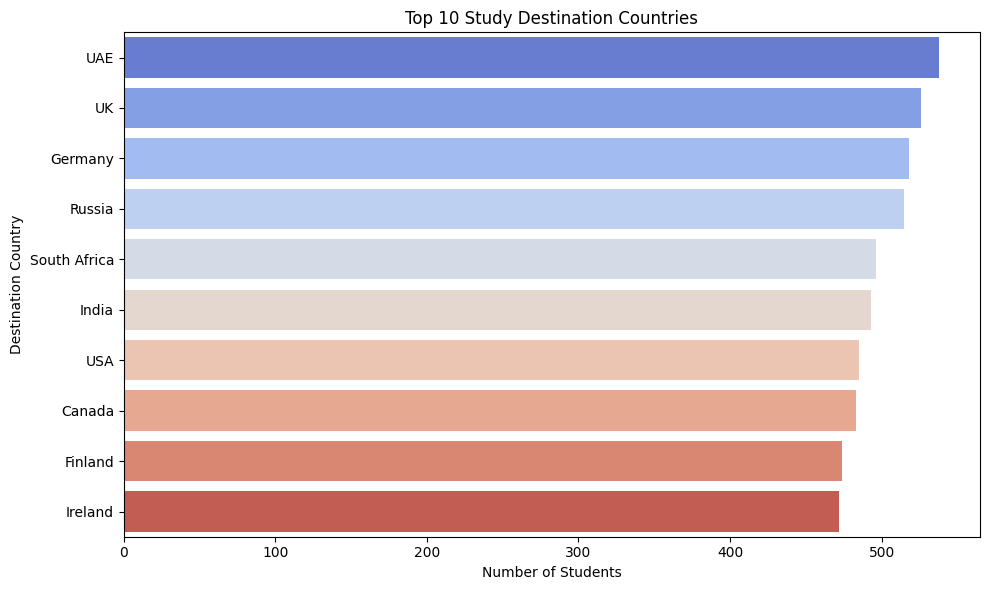

In [14]:
# 2. Top 10 Destination Countries
top_destinations = df['destination_country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_destinations.values, y=top_destinations.index, palette='coolwarm')
plt.title('Top 10 Study Destination Countries')
plt.xlabel('Number of Students')
plt.ylabel('Destination Country')
plt.tight_layout()
plt.show()

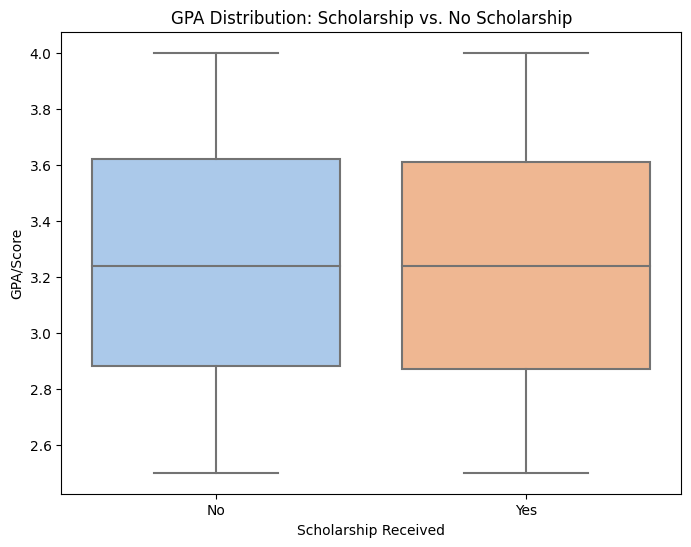

In [15]:
# 3. Scholarship vs GPA
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='scholarship_received', y='gpa_or_score', palette='pastel')
plt.title('GPA Distribution: Scholarship vs. No Scholarship')
plt.xlabel('Scholarship Received')
plt.ylabel('GPA/Score')
plt.show()

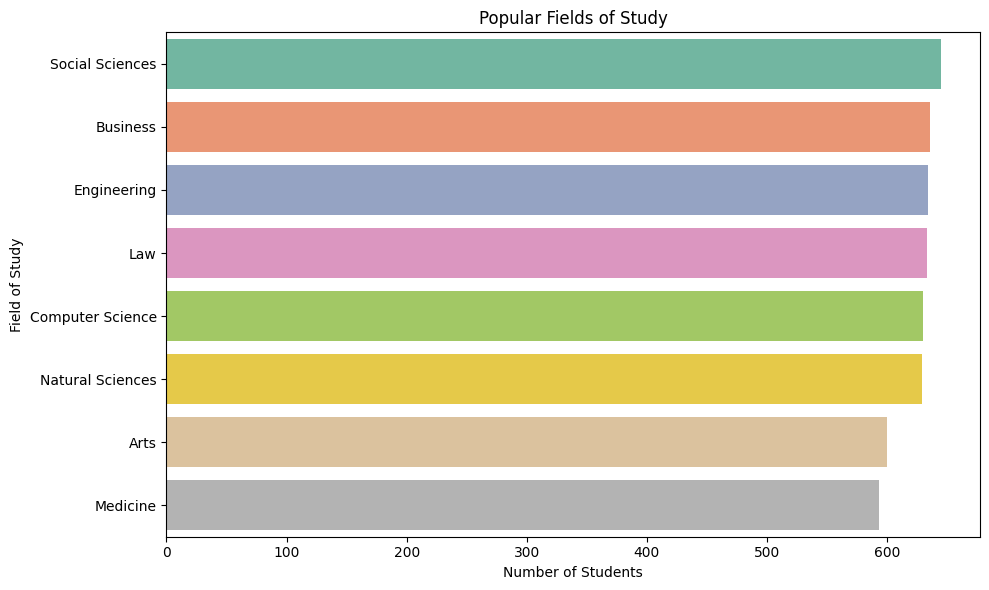

In [16]:
# 4. Field of Study Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='field_of_study', order=df['field_of_study'].value_counts().index, palette='Set2')
plt.title('Popular Fields of Study')
plt.xlabel('Number of Students')
plt.ylabel('Field of Study')
plt.tight_layout()
plt.show()

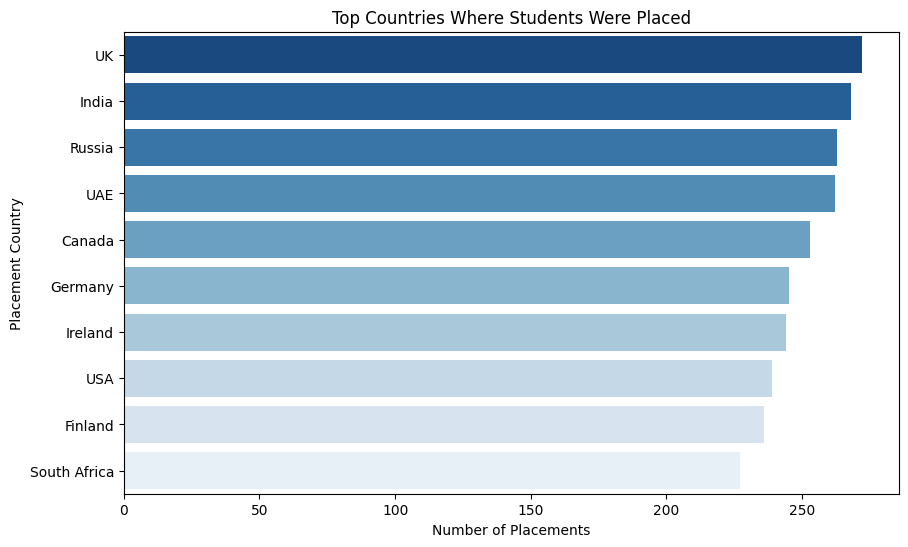

In [17]:
# 5. Placement Status by Country
placement = df[df['placement_status'] == 'Placed']
placement_count = placement['placement_country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=placement_count.values, y=placement_count.index, palette='Blues_r')
plt.title('Top Countries Where Students Were Placed')
plt.xlabel('Number of Placements')
plt.ylabel('Placement Country')
plt.show()


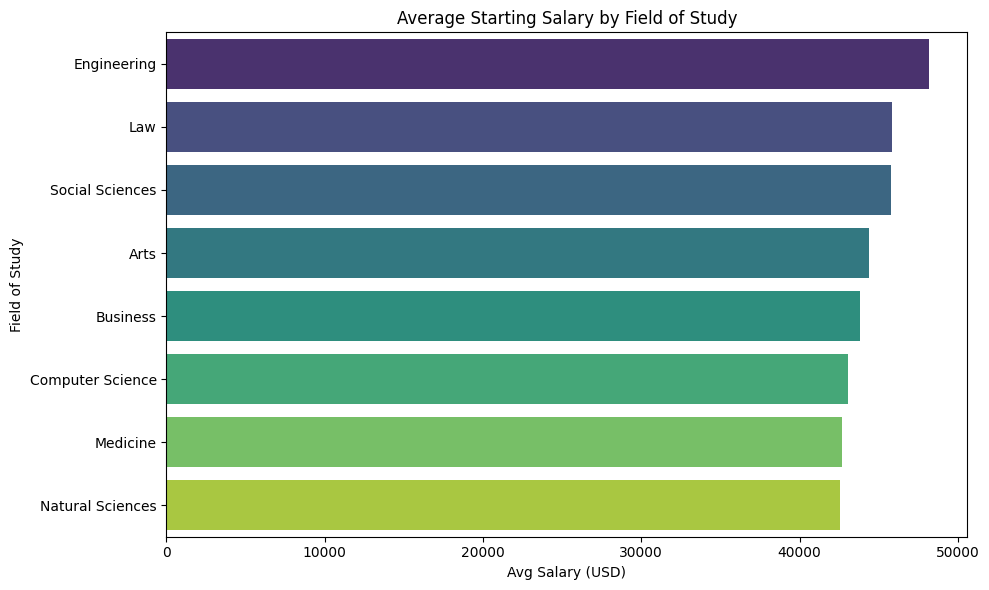

In [18]:
# 6. Average Starting Salary by Field
salary_field = df.groupby('field_of_study')['starting_salary_usd'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=salary_field.values, y=salary_field.index, palette='viridis')
plt.title('Average Starting Salary by Field of Study')
plt.xlabel('Avg Salary (USD)')
plt.ylabel('Field of Study')
plt.tight_layout()
plt.show()

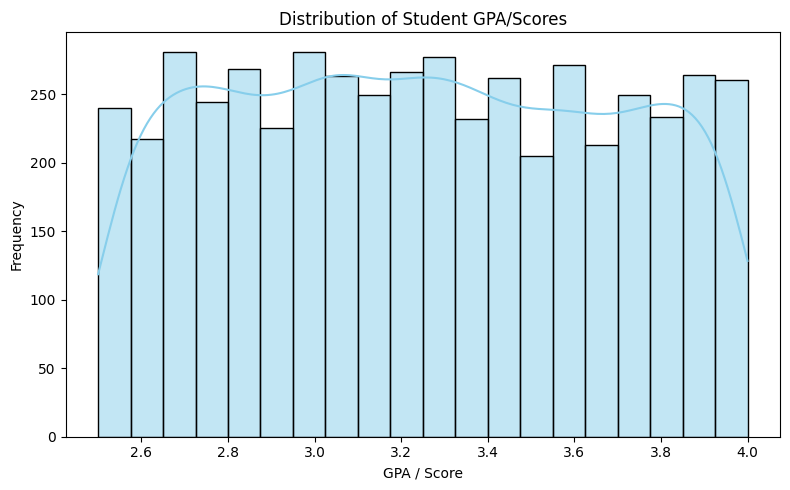

In [19]:
# 7. GPA Distribution Histogram
plt.figure(figsize=(8, 5))
sns.histplot(df['gpa_or_score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Student GPA/Scores')
plt.xlabel('GPA / Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

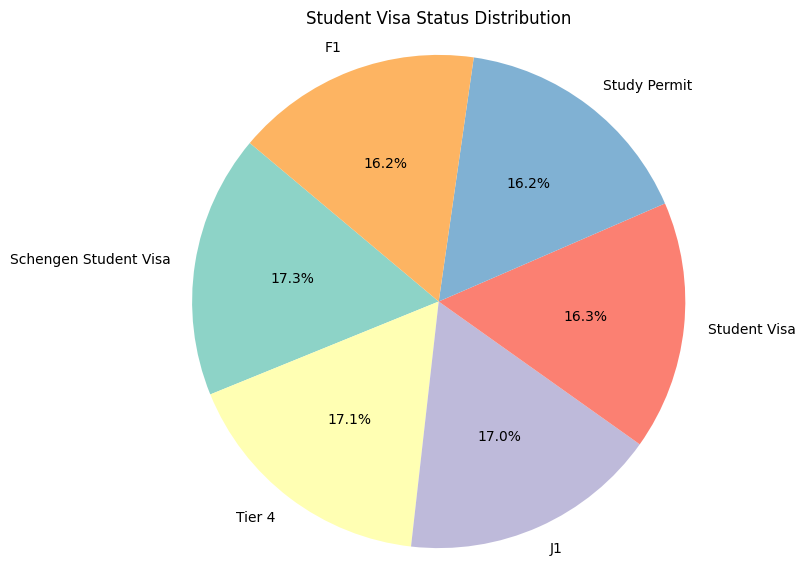

In [20]:
# 8. Visa Status Pie Chart
visa_counts = df['visa_status'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(visa_counts.values, labels=visa_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set3'))
plt.title('Student Visa Status Distribution')
plt.axis('equal')
plt.show()

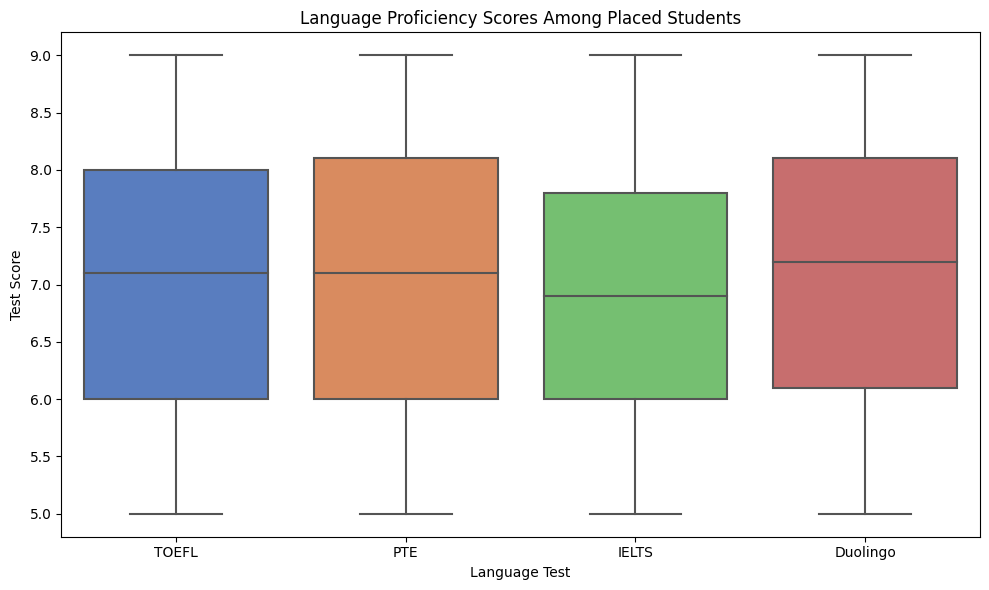

In [21]:
# 9. Language Proficiency Test Score vs Placement
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[df['placement_status'] == 'Placed'], x='language_proficiency_test', y='test_score', palette='muted')
plt.title('Language Proficiency Scores Among Placed Students')
plt.xlabel('Language Test')
plt.ylabel('Test Score')
plt.tight_layout()
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [23]:
# Drop columns with too much variability or leakage (e.g., student_id, placement_company)
drop_cols = ['student_id', 'placement_company', 'starting_salary_usd']
df.drop(columns=drop_cols, inplace=True)

# Handle missing values (simple fill or drop)
df.fillna(method='ffill', inplace=True)

# Encode target variable
df['placement_status'] = df['placement_status'].map({'Placed': 1, 'Not Placed': 0})

# Label encode categorical columns
label_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop('placement_status', axis=1)
y = df['placement_status']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Gradient Boosting': GradientBoostingClassifier()
}

# Train & Evaluate
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = round(acc, 2)

# Display accuracies
print("Model Accuracies:")
for model, acc in accuracy_results.items():
    print(f"{model}: {acc}%")

Model Accuracies:
Logistic Regression: 50.1%
Random Forest: 89.2%
Decision Tree: 81.6%
K-Nearest Neighbors: 66.2%
Support Vector Machine: 47.5%
Gradient Boosting: 90.6%


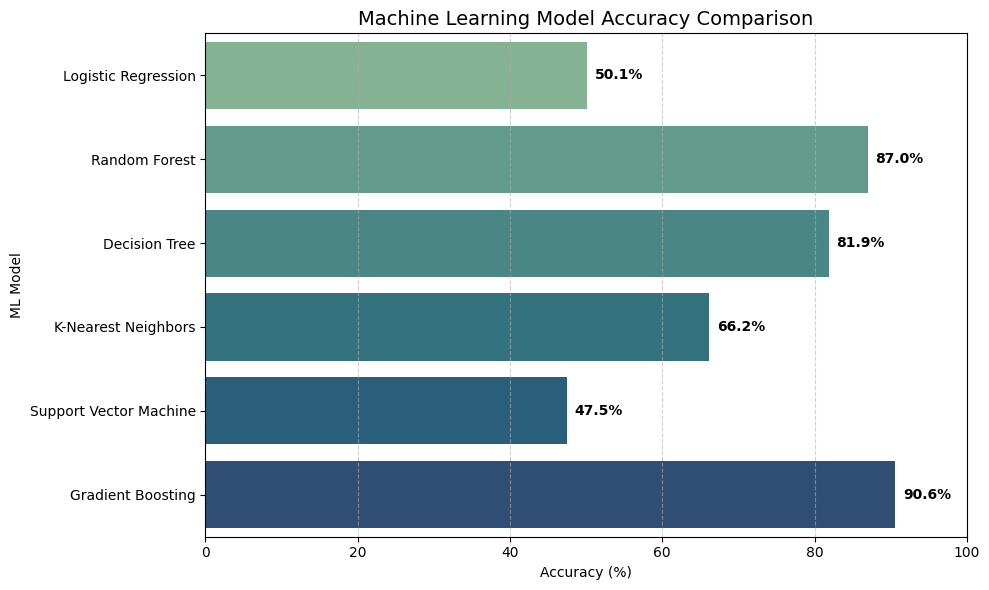

In [25]:
# Accuracy results (from your output)
accuracy_results = {
    'Logistic Regression': 50.1,
    'Random Forest': 87.0,
    'Decision Tree': 81.9,
    'K-Nearest Neighbors': 66.2,
    'Support Vector Machine': 47.5,
    'Gradient Boosting': 90.6
}

# Convert to DataFrame for easy plotting
import pandas as pd
acc_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=acc_df, x='Accuracy', y='Model', palette='crest', orient='h')

# Add accuracy values to bars
for index, value in enumerate(acc_df['Accuracy']):
    plt.text(value + 1, index, f"{value}%", va='center', fontweight='bold')

plt.title('Machine Learning Model Accuracy Comparison', fontsize=14)
plt.xlabel('Accuracy (%)')
plt.ylabel('ML Model')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!